In [1]:
import pandas as pd
import numpy as np
import os
import sys

print("Current directory:", os.getcwd())

# Add the machinelearning directory to the path (go up one level from features)
sys.path.insert(0, os.path.abspath(".."))
print("Added to path:", os.path.abspath(".."))

# Verify pipeline_links.py exists
import os
if os.path.exists("../pipeline_links.py"):
    print("✓ pipeline_links.py found!")
else:
    print("✗ pipeline_links.py not found at ../pipeline_links.py")
    print("Files in parent directory:", os.listdir(".."))

from pipeline_links import calculate_genre_similarity_features, get_genre_proportions_from_artist_list, genre_type_proportions_column_names, get_pg_conn

Current directory: /home/jonnym/Desktop/MelodyMap/internal/interlude_service/machinelearning/features
Added to path: /home/jonnym/Desktop/MelodyMap/internal/interlude_service/machinelearning
✗ pipeline_links.py not found at ../pipeline_links.py
Files in parent directory: ['DOCKER_QUICKSTART.md', '.pytest_cache', 'QUICKSTART.md', 'app.py', 'outputs', 'test.ipynb', 'Dockerfile', 'notebooks', 'run_pipeline.py', 'README.md', 'tests', 'training_data', 'feature_engineering', 'models', 'requirements.txt', '__pycache__', 'PIPELINE_SUMMARY.md', 'pytest.ini', 'config', 'runs', 'features', 'utils', '.dockerignore', 'etl']


In [2]:
conn = get_pg_conn()
src = pd.read_sql("SELECT id FROM artist ORDER BY RANDOM() LIMIT 1000000;", conn)
dst = pd.read_sql("SELECT id FROM artist ORDER BY RANDOM() LIMIT 1000000;", conn)
artist_ids = src['id'].tolist() + dst['id'].tolist()
src_df = get_genre_proportions_from_artist_list(artist_ids[:1000])
src_df = src_df.rename(columns={'artist_id': 'src'})
dst_df = get_genre_proportions_from_artist_list(artist_ids[1000:])
dst_df = dst_df.rename(columns={'artist_id': 'dst'})
genre_df = pd.concat([src_df, dst_df],axis=1)
genre_type = genre_type_proportions_column_names('dortmund')



/tmp/ipykernel_33162/4071865580.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  src = pd.read_sql("SELECT id FROM artist ORDER BY RANDOM() LIMIT 1000000;", conn)
/tmp/ipykernel_33162/4071865580.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dst = pd.read_sql("SELECT id FROM artist ORDER BY RANDOM() LIMIT 1000000;", conn)
/home/jonnym/Desktop/MelodyMap/internal/interlude_service/machinelearning/features/pipeline_links.py:436: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(q, conn, params=(artis

In [36]:
from config.config import ARTIST_COLLAB_NEG_CSV
df_features = pd.read_csv(ARTIST_COLLAB_NEG_CSV)

In [45]:
df_features.shape, df_features.dropna().shape

((60000, 54), (15125, 54))

In [37]:
[i for i in df_features.columns]

['cos_sim_src_dst',
 'l2_dist_src_dst',
 'dot_src_dst',
 'abs_diff_mean',
 'abs_diff_max',
 'popularity_src',
 'popularity_dst',
 'max_cos_srcnbr_dst',
 'mean_cos_srcnbr_dst',
 'mean_topk_cos_srcnbr_dst',
 'num_src_neighbors',
 'max_cos_dstnbr_src',
 'mean_cos_dstnbr_src',
 'mean_topk_cos_dstnbr_src',
 'num_dst_neighbors',
 'shared_neighbors',
 'jaccard_neighbors',
 'adamic_adar',
 'preferential_attachment',
 'src',
 'dst',
 'label',
 'similarity_prop_genre_dortmund_alternative',
 'similarity_prop_genre_dortmund_blues',
 'similarity_prop_genre_dortmund_electronic',
 'similarity_prop_genre_dortmund_folkcountry',
 'similarity_prop_genre_dortmund_funksoulrnb',
 'similarity_prop_genre_dortmund_jazz',
 'similarity_prop_genre_dortmund_pop',
 'similarity_prop_genre_dortmund_raphiphop',
 'similarity_prop_genre_dortmund_rock',
 'similarity_prop_genre_electronic_ambient',
 'similarity_prop_genre_electronic_dnb',
 'similarity_prop_genre_electronic_house',
 'similarity_prop_genre_electronic_techno

In [38]:
[i for i in df_features.columns if i.startswith('similarity_prop_genre_rosamerica')]

['similarity_prop_genre_rosamerica_cla',
 'similarity_prop_genre_rosamerica_dan',
 'similarity_prop_genre_rosamerica_hip',
 'similarity_prop_genre_rosamerica_jaz',
 'similarity_prop_genre_rosamerica_pop',
 'similarity_prop_genre_rosamerica_rhy',
 'similarity_prop_genre_rosamerica_roc',
 'similarity_prop_genre_rosamerica_spe']

In [39]:
genre_type = genre_type_proportions_column_names('rosamerica')

gt = ["similarity_prop_" + i for i in genre_type]

array([[<Axes: title={'center': 'similarity_prop_genre_rosamerica_cla'}>,
        <Axes: title={'center': 'similarity_prop_genre_rosamerica_dan'}>,
        <Axes: title={'center': 'similarity_prop_genre_rosamerica_hip'}>],
       [<Axes: title={'center': 'similarity_prop_genre_rosamerica_jaz'}>,
        <Axes: title={'center': 'similarity_prop_genre_rosamerica_pop'}>,
        <Axes: title={'center': 'similarity_prop_genre_rosamerica_rhy'}>],
       [<Axes: title={'center': 'similarity_prop_genre_rosamerica_roc'}>,
        <Axes: title={'center': 'similarity_prop_genre_rosamerica_spe'}>,
        <Axes: >]], dtype=object)

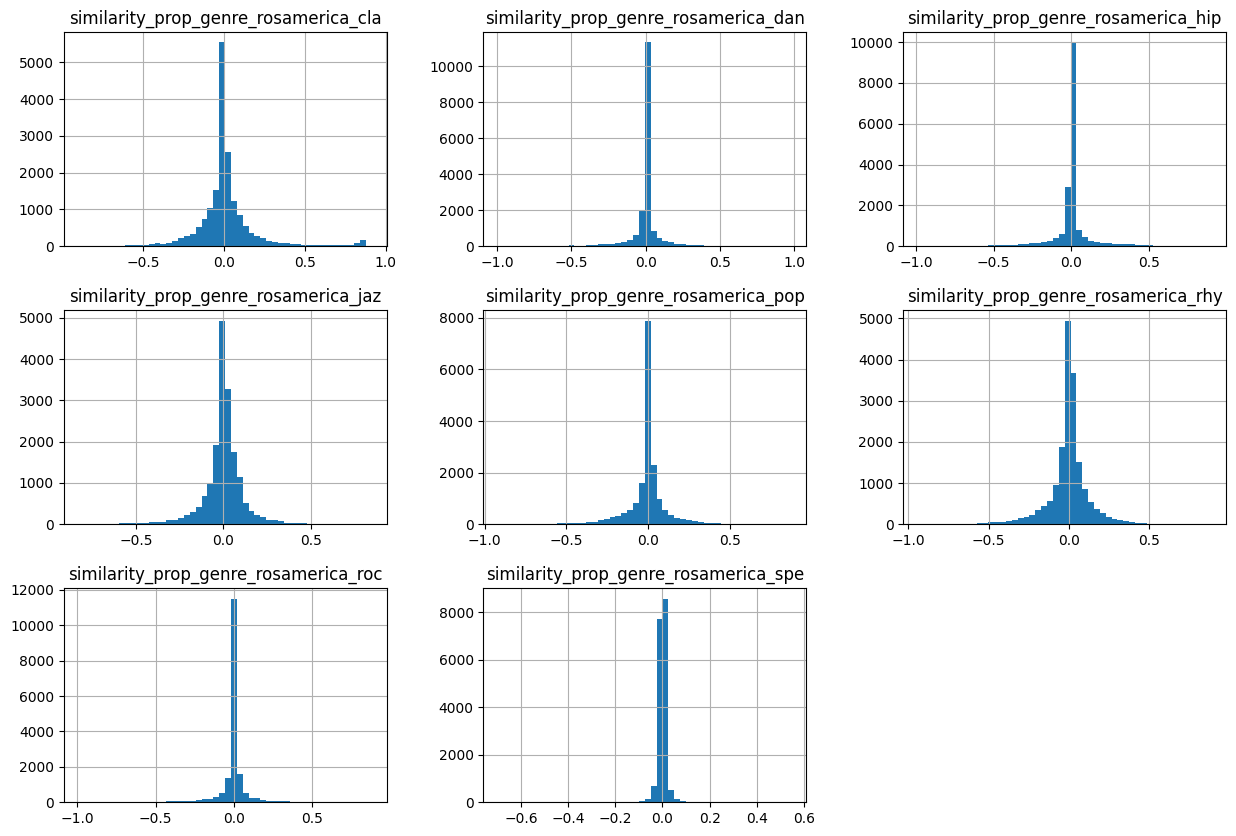

In [40]:
# Plot out the distributions of the genre similarity features
df_features[gt].hist(bins=50, figsize=(15,10))

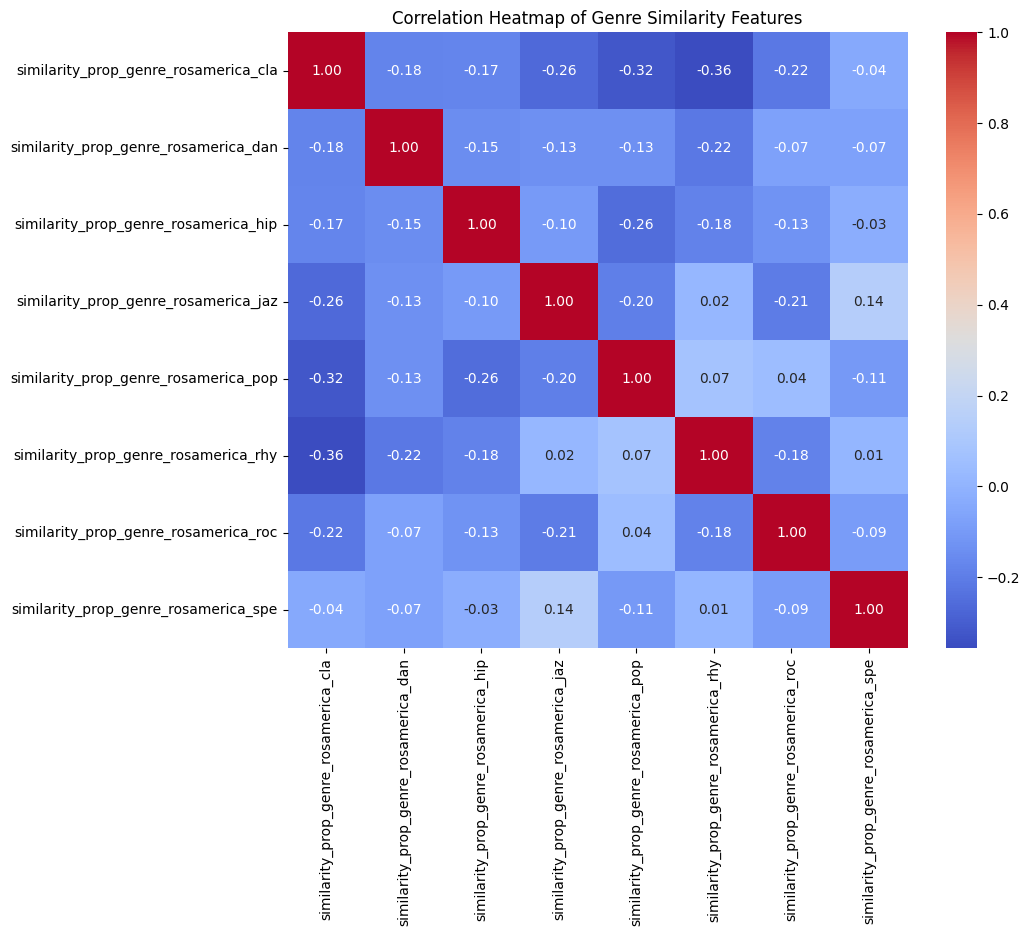

In [41]:
# Now a heatmap of the correlations
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_features[gt].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Genre Similarity Features")
plt.show()

In [42]:
# Now lets see the vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df_features[gt].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)
# Got inf, meaning perfect multicollinearity

                                feature  VIF
0  similarity_prop_genre_rosamerica_cla  inf
1  similarity_prop_genre_rosamerica_dan  inf
2  similarity_prop_genre_rosamerica_hip  inf
3  similarity_prop_genre_rosamerica_jaz  inf
4  similarity_prop_genre_rosamerica_pop  inf
5  similarity_prop_genre_rosamerica_rhy  inf
6  similarity_prop_genre_rosamerica_roc  inf
7  similarity_prop_genre_rosamerica_spe  inf


/home/jonnym/.local/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [43]:
# Now combine all of this together, vif and correlation heatmap to decide which features to drop
# Now do the vif after dropping one feature

X_dropped = X.drop(columns=[gt[0]])
vif_data_dropped = pd.DataFrame()
vif_data_dropped["feature"] = X_dropped.columns
vif_data_dropped["VIF"] = [variance_inflation_factor(X_dropped.values, i) for i in range(len(X_dropped.columns))]
print(vif_data_dropped)

                                feature       VIF
0  similarity_prop_genre_rosamerica_dan  1.243228
1  similarity_prop_genre_rosamerica_hip  1.294917
2  similarity_prop_genre_rosamerica_jaz  1.207847
3  similarity_prop_genre_rosamerica_pop  1.213247
4  similarity_prop_genre_rosamerica_rhy  1.191250
5  similarity_prop_genre_rosamerica_roc  1.186756
6  similarity_prop_genre_rosamerica_spe  1.043098


In [ ]:
# The rosamerica feature has very low multicollinearity compared to the rest

In [35]:
X_dropped.columns

Index(['similarity_prop_genre_rosamerica_dan',
       'similarity_prop_genre_rosamerica_hip',
       'similarity_prop_genre_rosamerica_jaz',
       'similarity_prop_genre_rosamerica_pop',
       'similarity_prop_genre_rosamerica_rhy',
       'similarity_prop_genre_rosamerica_roc',
       'similarity_prop_genre_rosamerica_spe'],
      dtype='object')

In [20]:
# Now do the vif after dropping one feature
X_dropped = X.drop(columns=[gt[0]])
vif_data_dropped = pd.DataFrame()
vif_data_dropped["feature"] = X_dropped.columns
vif_data_dropped["VIF"] = [variance_inflation_factor(X_dropped.values, i) for i in range(len(X_dropped.columns))]
print(vif_data_dropped)

                                      feature        VIF
0        similarity_prop_genre_dortmund_blues   9.535779
1   similarity_prop_genre_dortmund_electronic  71.684086
2  similarity_prop_genre_dortmund_folkcountry  16.033322
3  similarity_prop_genre_dortmund_funksoulrnb   3.449783
4         similarity_prop_genre_dortmund_jazz   4.867840
5          similarity_prop_genre_dortmund_pop   3.319673
6    similarity_prop_genre_dortmund_raphiphop   2.981996
7         similarity_prop_genre_dortmund_rock   5.422153


In [65]:
pd.set_option('display.max_columns', None)
df_features.head()

,cos_sim_src_dst,l2_dist_src_dst,dot_src_dst,abs_diff_mean,abs_diff_max,popularity_src,popularity_dst,max_cos_srcnbr_dst,mean_cos_srcnbr_dst,mean_topk_cos_srcnbr_dst,num_src_neighbors,max_cos_dstnbr_src,mean_cos_dstnbr_src,mean_topk_cos_dstnbr_src,num_dst_neighbors,shared_neighbors,jaccard_neighbors,adamic_adar,preferential_attachment,src,dst,label,genre_sim_prop_genre_dortmund_alternative,genre_sim_prop_genre_dortmund_blues,genre_sim_prop_genre_dortmund_electronic,genre_sim_prop_genre_dortmund_folkcountry,genre_sim_prop_genre_dortmund_funksoulrnb,genre_sim_prop_genre_dortmund_jazz,genre_sim_prop_genre_dortmund_pop,genre_sim_prop_genre_dortmund_raphiphop,genre_sim_prop_genre_dortmund_rock,genre_sim_prop_genre_electronic_ambient,genre_sim_prop_genre_electronic_dnb,genre_sim_prop_genre_electronic_house,genre_sim_prop_genre_electronic_techno,genre_sim_prop_genre_electronic_trance,genre_sim_prop_genre_rosamerica_cla,genre_sim_prop_genre_rosamerica_dan,genre_sim_prop_genre_rosamerica_hip,genre_sim_prop_genre_rosamerica_jaz,genre_sim_prop_genre_rosamerica_pop,genre_sim_prop_genre_rosamerica_rhy,genre_sim_prop_genre_rosamerica_roc,genre_sim_prop_genre_rosamerica_spe,genre_sim_prop_genre_tzanetakis_blu,genre_sim_prop_genre_tzanetakis_cla,genre_sim_prop_genre_tzanetakis_cou,genre_sim_prop_genre_tzanetakis_dis,genre_sim_prop_genre_tzanetakis_hip,genre_sim_prop_genre_tzanetakis_jaz,genre_sim_prop_genre_tzanetakis_met,genre_sim_prop_genre_tzanetakis_pop,genre_sim_prop_genre_tzanetakis_reg,genre_sim_prop_genre_tzanetakis_roc
0,0.604237,0.889677,0.604237,0.128361,0.363773,5.6390,2.9552,0.914596,0.906673,0.906673,2,0.702064,0.702064,0.702064,1,0,0.0,0.0,9,10239,759294,1,0.008243,-0.096294,0.129421,-0.040794,0.000014,-0.003668,0.001458,0.002129,-0.000509,0.029234,-0.001484,-0.052710,0.001405,0.023555,0.004835,0.001328,0.001680,-0.023945,0.010931,0.007418,0.005748,-0.007995,-0.006195,-0.036650,-0.003991,0.003363,-0.026857,0.037797,0.001212,0.004257,-0.005585,0.032650
1,0.684117,0.794837,0.684117,0.112670,0.318297,4.2302,5.1265,0.000000,0.000000,0.000000,0,1.000000,1.000000,1.000000,1,0,0.0,0.0,9,851262,2191869,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.752728,0.703239,0.752728,0.103697,0.340234,5.4330,3.6481,0.000000,0.000000,0.000000,0,1.000000,1.000000,1.000000,1,0,0.0,0.0,4,806103,1269348,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.629845,0.860412,0.629845,0.121512,0.349548,3.4858,1.4870,0.677458,0.677458,0.677458,1,1.000000,1.000000,1.000000,1,0,0.0,0.0,9,473373,865865,1,-0.000043,0.043714,-0.034696,0.022221,-0.000347,-0.029733,-0.002834,0.001595,0.000122,-0.007527,0.000841,-0.000914,0.004308,0.003292,0.002694,0.000491,0.005027,-0.034627,-0.003545,-0.008266,0.000909,0.037317,0.024554,0.017327,0.024511,0.020063,0.032338,-0.094499,0.005819,0.010086,0.007730,-0.047929
4,0.908341,0.428156,0.908341,0.058779,0.187112,4.2628,6.0460,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0,0.0,0.0,6,788415,916677,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
genre_df.head()

,src,prop_genre_dortmund_alternative,prop_genre_dortmund_blues,prop_genre_dortmund_electronic,prop_genre_dortmund_folkcountry,prop_genre_dortmund_funksoulrnb,prop_genre_dortmund_jazz,prop_genre_dortmund_pop,prop_genre_dortmund_raphiphop,prop_genre_dortmund_rock,...,prop_genre_tzanetakis_blu,prop_genre_tzanetakis_cla,prop_genre_tzanetakis_cou,prop_genre_tzanetakis_dis,prop_genre_tzanetakis_hip,prop_genre_tzanetakis_jaz,prop_genre_tzanetakis_met,prop_genre_tzanetakis_pop,prop_genre_tzanetakis_reg,prop_genre_tzanetakis_roc
0,15023.0,3.407466e-02,6.163576e-02,0.782895,6.169822e-02,4.121806e-03,1.277975e-02,7.267573e-03,2.283326e-03,3.324387e-02,...,0.056011,0.032728,0.083038,0.060699,0.127131,0.371730,0.044235,0.063021,0.058825,0.102582
1,31906.0,9.078507e-02,5.662523e-02,0.481274,2.421260e-01,5.739454e-03,2.321422e-02,5.249856e-02,3.271618e-03,4.446535e-02,...,0.062654,0.034813,0.078350,0.104548,0.156936,0.313987,0.044816,0.062735,0.062735,0.078425
2,41324.0,5.621543e-03,6.326344e-04,0.983486,8.671514e-04,1.026113e-04,5.579692e-03,7.605192e-04,5.617606e-04,2.388398e-03,...,0.048290,0.034125,0.043109,0.034585,0.124253,0.570009,0.020288,0.036799,0.034152,0.054389
3,47406.0,6.658852e-02,1.370329e-02,0.855294,7.602212e-03,2.341383e-03,4.319594e-03,3.068102e-03,1.740886e-03,4.534174e-02,...,0.061771,0.035002,0.098357,0.078026,0.153506,0.302215,0.045606,0.065391,0.064402,0.095723
4,48466.0,1.835812e-10,1.897666e-10,0.999999,3.994089e-08,1.600970e-08,7.620654e-07,1.754036e-08,1.592241e-08,1.369224e-07,...,0.057936,0.034507,0.097011,0.066736,0.145532,0.347191,0.042718,0.063568,0.059531,0.085269


In [39]:
src_df = df_features[['src']].merge(genre_df, on='src', how='left')
dst_df = df_features[['dst']].merge(genre_df, left_on='dst', right_on = 'src', how='left')
dst_df = dst_df.drop(columns=['src']).rename(columns={'dst_x':'dst'})

In [49]:
res = pd.DataFrame(src_df.iloc[:,1:].to_numpy() - dst_df.iloc[:,1:].to_numpy(),columns=dst_df.columns[1:])

In [50]:
res['src'] = df_features['src']
res['dst'] = df_features['dst']

In [51]:
res.head()

,prop_genre_dortmund_alternative,prop_genre_dortmund_blues,prop_genre_dortmund_electronic,prop_genre_dortmund_folkcountry,prop_genre_dortmund_funksoulrnb,prop_genre_dortmund_jazz,prop_genre_dortmund_pop,prop_genre_dortmund_raphiphop,prop_genre_dortmund_rock,prop_genre_electronic_ambient,...,prop_genre_tzanetakis_cou,prop_genre_tzanetakis_dis,prop_genre_tzanetakis_hip,prop_genre_tzanetakis_jaz,prop_genre_tzanetakis_met,prop_genre_tzanetakis_pop,prop_genre_tzanetakis_reg,prop_genre_tzanetakis_roc,src,dst
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98723,1294434
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245294,1213145
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500373,1526784
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1219832,1219919
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35100,498363


In [35]:
src_df.head()

,src,prop_genre_dortmund_alternative,prop_genre_dortmund_blues,prop_genre_dortmund_electronic,prop_genre_dortmund_folkcountry,prop_genre_dortmund_funksoulrnb,prop_genre_dortmund_jazz,prop_genre_dortmund_pop,prop_genre_dortmund_raphiphop,prop_genre_dortmund_rock,...,prop_genre_tzanetakis_blu,prop_genre_tzanetakis_cla,prop_genre_tzanetakis_cou,prop_genre_tzanetakis_dis,prop_genre_tzanetakis_hip,prop_genre_tzanetakis_jaz,prop_genre_tzanetakis_met,prop_genre_tzanetakis_pop,prop_genre_tzanetakis_reg,prop_genre_tzanetakis_roc
0,98723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,245294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1500373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1219832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
dst_df.head()

,dst_x,src,prop_genre_dortmund_alternative,prop_genre_dortmund_blues,prop_genre_dortmund_electronic,prop_genre_dortmund_folkcountry,prop_genre_dortmund_funksoulrnb,prop_genre_dortmund_jazz,prop_genre_dortmund_pop,prop_genre_dortmund_raphiphop,...,prop_genre_tzanetakis_blu,prop_genre_tzanetakis_cla,prop_genre_tzanetakis_cou,prop_genre_tzanetakis_dis,prop_genre_tzanetakis_hip,prop_genre_tzanetakis_jaz,prop_genre_tzanetakis_met,prop_genre_tzanetakis_pop,prop_genre_tzanetakis_reg,prop_genre_tzanetakis_roc
0,1294434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1213145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1526784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1219919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,498363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
[i for i in genre_df.columns if "src" in i or "dst" in i]
cols = [i for i in genre_df.columns if "src" in i or "dst" in i] + genre_type_proportions_column_names('dortmund')
# new_df.head()
cols

['src',
 'dst',
 'genre_dortmund_alternative',
 'genre_dortmund_blues',
 'genre_dortmund_electronic',
 'genre_dortmund_folkcountry',
 'genre_dortmund_funksoulrnb',
 'genre_dortmund_jazz',
 'genre_dortmund_pop',
 'genre_dortmund_raphiphop',
 'genre_dortmund_rock']

In [30]:
[i for i in genre_df.columns]

['src',
 'prop_genre_dortmund_alternative',
 'prop_genre_dortmund_blues',
 'prop_genre_dortmund_electronic',
 'prop_genre_dortmund_folkcountry',
 'prop_genre_dortmund_funksoulrnb',
 'prop_genre_dortmund_jazz',
 'prop_genre_dortmund_pop',
 'prop_genre_dortmund_raphiphop',
 'prop_genre_dortmund_rock',
 'prop_genre_electronic_ambient',
 'prop_genre_electronic_dnb',
 'prop_genre_electronic_house',
 'prop_genre_electronic_techno',
 'prop_genre_electronic_trance',
 'prop_genre_rosamerica_cla',
 'prop_genre_rosamerica_dan',
 'prop_genre_rosamerica_hip',
 'prop_genre_rosamerica_jaz',
 'prop_genre_rosamerica_pop',
 'prop_genre_rosamerica_rhy',
 'prop_genre_rosamerica_roc',
 'prop_genre_rosamerica_spe',
 'prop_genre_tzanetakis_blu',
 'prop_genre_tzanetakis_cla',
 'prop_genre_tzanetakis_cou',
 'prop_genre_tzanetakis_dis',
 'prop_genre_tzanetakis_hip',
 'prop_genre_tzanetakis_jaz',
 'prop_genre_tzanetakis_met',
 'prop_genre_tzanetakis_pop',
 'prop_genre_tzanetakis_reg',
 'prop_genre_tzanetakis_roc

In [4]:
if not genre_df.empty:
    genre_lookup = genre_df.set_index(['src','dst']).to_dict(orient='index')
    print("Calculating genre similarity features...")

    genre_feature_rows = []
    for _, row in genre_df.iterrows():
        src_id = row['src']
        dst_id = row['dst']
        src_genres = genre_lookup.get(src_id, {})
        dst_genres = genre_lookup.get(dst_id, {})
        
        if src_genres and dst_genres:
            src_genre_values = [src_genres.get(col, 0.0) for col in genre_type_proportions_column_names('dortmund') if col != 'artist_id']
            dst_genre_values = [dst_genres.get(col, 0.0) for col in genre_type_proportions_column_names('dortmund') if col != 'artist_id']
            
            genre_sim_features = calculate_genre_similarity_features(
                list_of_genre_proportions=[col for col in genre_type_proportions_column_names('dortmund') if col != 'artist_id'],
                src_genres=src_genre_values,
                dst_genres=dst_genre_values
            )
            genre_feature_rows.append(genre_sim_features)
        else:
            genre_feature_rows.append({})

genre_features_df = pd.DataFrame(genre_feature_rows)
genre_df = pd.concat([genre_df.reset_index(drop=True), genre_features_df.reset_index(drop=True)], axis=1)
print("Added genre similarity features to dataset.")


/tmp/ipykernel_51429/3650919611.py:2: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  genre_lookup = genre_df.set_index(['src','dst']).to_dict(orient='index')


Calculating genre similarity features...
Added genre similarity features to dataset.


In [12]:
genre_df.head()

,src,prop_genre_dortmund_alternative,prop_genre_dortmund_blues,prop_genre_dortmund_electronic,prop_genre_dortmund_folkcountry,prop_genre_dortmund_funksoulrnb,prop_genre_dortmund_jazz,prop_genre_dortmund_pop,prop_genre_dortmund_raphiphop,prop_genre_dortmund_rock,...,prop_genre_tzanetakis_blu,prop_genre_tzanetakis_cla,prop_genre_tzanetakis_cou,prop_genre_tzanetakis_dis,prop_genre_tzanetakis_hip,prop_genre_tzanetakis_jaz,prop_genre_tzanetakis_met,prop_genre_tzanetakis_pop,prop_genre_tzanetakis_reg,prop_genre_tzanetakis_roc
0,949.0,0.055074,0.047977,0.728040,0.068434,0.007079,0.018206,0.010456,0.008390,0.056345,...,0.067135,0.035831,0.101837,0.076538,0.153423,0.305101,0.045056,0.064239,0.070787,0.080054
1,1338.0,0.046222,0.179066,0.481921,0.103280,0.008559,0.111689,0.013201,0.009188,0.046874,...,0.056011,0.032728,0.083038,0.060699,0.127131,0.371730,0.044235,0.063021,0.058825,0.102582
2,9800.0,0.019895,0.010960,0.944926,0.006913,0.001215,0.007239,0.001188,0.000936,0.006729,...,0.062654,0.034813,0.078350,0.104548,0.156936,0.313987,0.044816,0.062735,0.062735,0.078425
3,39874.0,0.044081,0.011364,0.884154,0.033627,0.001626,0.005075,0.005155,0.001059,0.013859,...,0.062622,0.037370,0.101139,0.072036,0.156229,0.300027,0.047729,0.069898,0.063849,0.089099
4,69102.0,0.000506,0.000047,0.999065,0.000095,0.000006,0.000168,0.000019,0.000006,0.000088,...,0.048290,0.034125,0.043109,0.034585,0.124253,0.570009,0.020288,0.036799,0.034152,0.054389


In [15]:
from config.config import ARTIST_COLLAB_NEG_CSV
df_src = pd.read_csv(ARTIST_COLLAB_NEG_CSV)

In [16]:
df_src.head()

,cos_sim_src_dst,l2_dist_src_dst,dot_src_dst,abs_diff_mean,abs_diff_max,popularity_src,popularity_dst,max_cos_srcnbr_dst,mean_cos_srcnbr_dst,mean_topk_cos_srcnbr_dst,...,label,genre_sim_feature_genre_dortmund_alternative,genre_sim_feature_genre_dortmund_blues,genre_sim_feature_genre_dortmund_electronic,genre_sim_feature_genre_dortmund_folkcountry,genre_sim_feature_genre_dortmund_funksoulrnb,genre_sim_feature_genre_dortmund_jazz,genre_sim_feature_genre_dortmund_pop,genre_sim_feature_genre_dortmund_raphiphop,genre_sim_feature_genre_dortmund_rock
0,0.648762,0.838139,0.648762,0.124233,0.349400,5.7843,5.5919,0.00000,0.000000,0.000000,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.663544,0.820312,0.663544,0.125080,0.349122,5.5416,2.4145,0.61131,0.606809,0.606809,...,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.524934,0.974747,0.524934,0.135801,0.423280,4.8353,6.6606,0.00000,0.000000,0.000000,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.932374,0.367765,0.932374,0.048633,0.204892,6.1404,0.6391,1.00000,0.988070,0.988070,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.943214,0.337004,0.943214,0.047682,0.170531,NaN,NaN,1.00000,1.000000,1.000000,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
[i for i in genre_df.columns]

['src',
 'prop_genre_dortmund_alternative',
 'prop_genre_dortmund_blues',
 'prop_genre_dortmund_electronic',
 'prop_genre_dortmund_folkcountry',
 'prop_genre_dortmund_funksoulrnb',
 'prop_genre_dortmund_jazz',
 'prop_genre_dortmund_pop',
 'prop_genre_dortmund_raphiphop',
 'prop_genre_dortmund_rock',
 'prop_genre_electronic_ambient',
 'prop_genre_electronic_dnb',
 'prop_genre_electronic_house',
 'prop_genre_electronic_techno',
 'prop_genre_electronic_trance',
 'prop_genre_rosamerica_cla',
 'prop_genre_rosamerica_dan',
 'prop_genre_rosamerica_hip',
 'prop_genre_rosamerica_jaz',
 'prop_genre_rosamerica_pop',
 'prop_genre_rosamerica_rhy',
 'prop_genre_rosamerica_roc',
 'prop_genre_rosamerica_spe',
 'prop_genre_tzanetakis_blu',
 'prop_genre_tzanetakis_cla',
 'prop_genre_tzanetakis_cou',
 'prop_genre_tzanetakis_dis',
 'prop_genre_tzanetakis_hip',
 'prop_genre_tzanetakis_jaz',
 'prop_genre_tzanetakis_met',
 'prop_genre_tzanetakis_pop',
 'prop_genre_tzanetakis_reg',
 'prop_genre_tzanetakis_roc

In [21]:
x = [.5,.5,.5]
y = [.1,.2,.3]
np.subtract(x,y)

array([0.4, 0.3, 0.2])

In [28]:
for i in range(len(df.columns)):
    df.iloc[:, i]

In [ ]:
df.iloc[:,1] # This gets the first genre proportion column

0        0.059620
1        0.011869
2        0.008082
3        0.047762
4        0.000961
           ...   
96586    0.001740
96587    0.154573
96588    0.262001
96589    0.058175
96590    0.018490
Name: prop_genre_dortmund_alternative, Length: 96591, dtype: float64

In [19]:
res['genre_sim_feature_genre_dortmund_alternative'].value_counts()

genre_sim_feature_genre_dortmund_alternative
0.9    96591
Name: count, dtype: int64